# 03 — Treinamento e Comparação dos Modelos

Agora é a parte mais legal: treinar e comparar **5 modelos diferentes** pra ver qual se sai melhor no nosso problema.

A escolha dos 5 foi pensada pra ter modelos com características bem diferentes — uns mais simples e interpretáveis, outros mais complexos:

- **Logistic Regression** — bem simples e fácil de explicar (os coeficientes dizem o quanto cada feature pesa).
- **KNN** — não tem treino de verdade, só compara com os vizinhos mais próximos.
- **SVM** — costuma ir bem em problemas com muitas features.
- **Random Forest** — várias árvores votando, robusto e popular.
- **Decision Tree** — uma árvore só, fácil de visualizar mas tende a sobreajustar.

A métrica de seleção foi **recall**, porque num diagnóstico de câncer não dá pra deixar caso maligno passar.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data
from src.preprocessing import build_preprocessing_pipeline, split_data
from src.models import get_all_models, train_all_models, get_best_model
from src.evaluate import (
    evaluate_all_models, cross_validate_model, plot_confusion_matrix,
    plot_roc_curves, plot_metrics_comparison,
)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sns.set_style('whitegrid')

## 1. Carregamento e divisão dos dados

In [2]:
df = load_data(save_csv=False)
X_train, X_val, X_test, y_train, y_val, y_test = split_data(df)
preprocessing = build_preprocessing_pipeline()
models = get_all_models()
list(models.keys())

['Logistic Regression', 'KNN', 'SVM', 'Random Forest', 'Decision Tree']

## 2. Treinamento de todos os modelos

In [3]:
trained = train_all_models(models, preprocessing, X_train, y_train)
print('Modelos treinados:', list(trained.keys()))

Modelos treinados: ['Logistic Regression', 'KNN', 'SVM', 'Random Forest', 'Decision Tree']


## 3. Validação cruzada (5-fold estratificada, recall)

In [4]:
cv_rows = []
for name, pipe in trained.items():
    mean, std = cross_validate_model(pipe, X_train, y_train, cv=5, scoring='recall')
    cv_rows.append({'model': name, 'recall_mean': mean, 'recall_std': std})
cv_df = pd.DataFrame(cv_rows).sort_values('recall_mean', ascending=False).reset_index(drop=True)
cv_df.style.format({'recall_mean': '{:.4f}', 'recall_std': '{:.4f}'})

,model,recall_mean,recall_std
0,SVM,0.9531,0.0339
1,Logistic Regression,0.9398,0.0489
2,Random Forest,0.9393,0.0396
3,KNN,0.9062,0.0571
4,Decision Tree,0.8724,0.0648


## 4. Métricas no conjunto de teste

In [5]:
results_df = evaluate_all_models(trained, X_test, y_test)
results_df.style.format({'accuracy': '{:.4f}', 'precision': '{:.4f}',
                          'recall': '{:.4f}', 'f1_score': '{:.4f}', 'roc_auc': '{:.4f}'})

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.9649,0.9750,0.9286,0.9512,0.9960
1,SVM,0.9649,0.9750,0.9286,0.9512,0.9934
2,Random Forest,0.9737,1.0000,0.9286,0.9630,0.9964
3,KNN,0.9561,0.9744,0.9048,0.9383,0.9828
4,Decision Tree,0.9211,0.9024,0.8810,0.8916,0.8914


## 5. Matriz de confusão de cada modelo

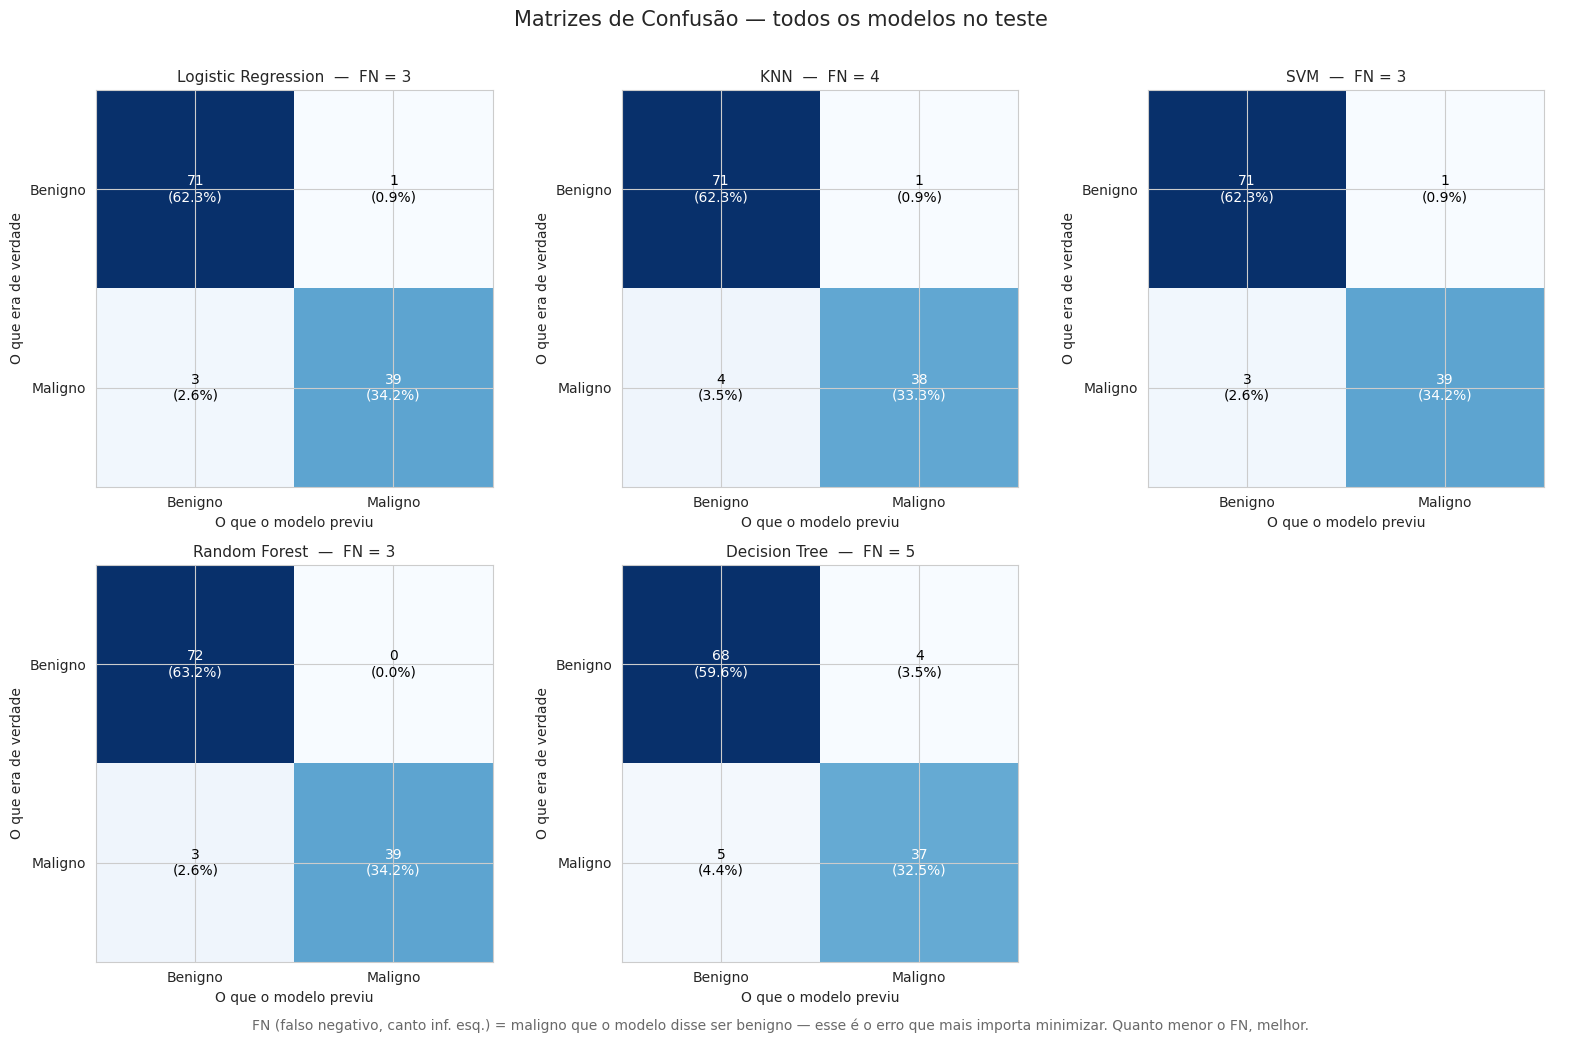

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (name, pipe) in zip(axes.flat, trained.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    total = cm.sum()
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno', 'Maligno'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    # refaço o texto pra mostrar abs + % em cada célula
    for txt in ax.texts:
        txt.remove()
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            v = cm[i, j]
            pct = v / total * 100
            color = 'white' if v > thresh else 'black'
            ax.text(j, i, f'{v}\n({pct:.1f}%)', ha='center', va='center', color=color, fontsize=10)
    # destaca o número de falsos negativos no título (canto inf. esquerdo)
    fn = cm[1, 0]
    ax.set_title(f'{name}  —  FN = {fn}', fontsize=11)
    ax.set_xlabel('O que o modelo previu')
    ax.set_ylabel('O que era de verdade')

for ax in axes.flat[len(trained):]:
    ax.axis('off')

fig.suptitle('Matrizes de Confusão — todos os modelos no teste', fontsize=15, y=1.01)
fig.text(0.5, -0.01,
         'FN (falso negativo, canto inf. esq.) = maligno que o modelo disse ser benigno — '
         'esse é o erro que mais importa minimizar. Quanto menor o FN, melhor.',
         ha='center', fontsize=10, color='dimgray')
plt.tight_layout()
plt.show()

## 6. Curvas ROC — todos os modelos

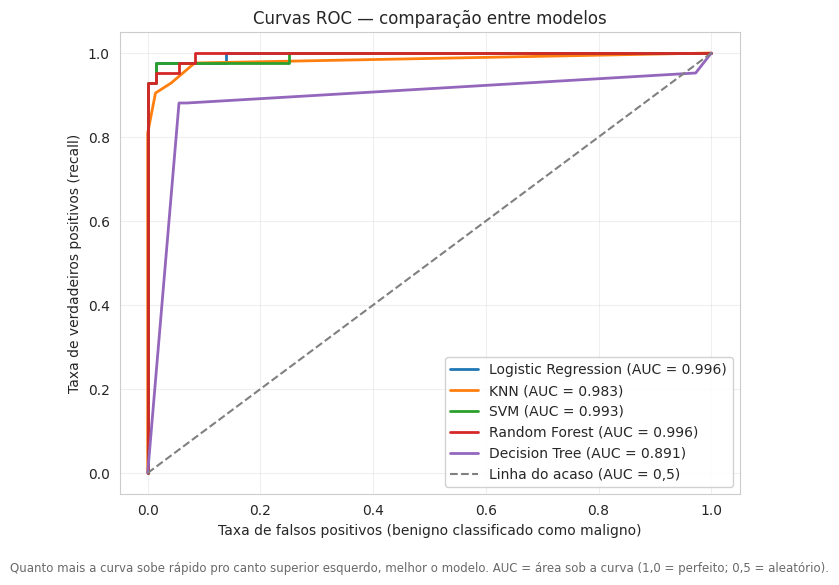

In [7]:
plot_roc_curves(trained, X_test, y_test)
plt.show()

## 7. Comparação visual de métricas

/usr/local/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dty

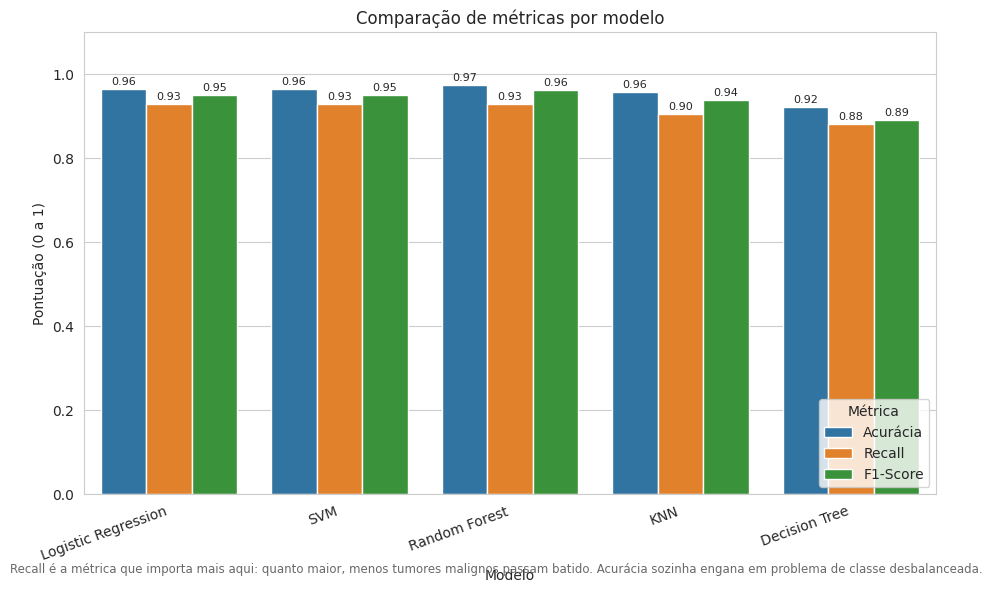

In [8]:
plot_metrics_comparison(results_df)
plt.show()

## 8. Seleção do melhor modelo (por recall)

In [9]:
results_dict = {row['model']: row.to_dict() for _, row in results_df.iterrows()}
best_name, best_metrics = get_best_model(results_dict, metric='recall')
print(f'Melhor modelo por recall: {best_name}')
print(f'Recall: {best_metrics["recall"]:.4f} | F1: {best_metrics["f1_score"]:.4f} | ROC AUC: {best_metrics["roc_auc"]:.4f}')

Melhor modelo por recall: Logistic Regression
Recall: 0.9286 | F1: 0.9512 | ROC AUC: 0.9960


## 9. Discussão dos resultados

### Por que escolhi recall e não acurácia?

Esse foi um ponto que demorei pra entender direito. À primeira vista parece que acurácia seria a métrica óbvia, mas pensando bem ela engana num caso desse:

- **Falso negativo:** o modelo diz que está benigno, mas na verdade é maligno. A paciente vai pra casa achando que tá tudo bem, e o tumor continua crescendo. **Esse é o erro grave.**
- **Falso positivo:** o modelo diz que está maligno, mas na verdade é benigno. A paciente é mandada pra exames adicionais e leva um susto. É ruim, mas se resolve.

Então o que eu quero é **minimizar o número de pacientes doentes que passam batido**, e isso é exatamente o que o recall mede.

### Mas só recall não basta

Se eu quisesse 100% de recall, era só fazer o modelo dizer "maligno" pra todo mundo. Recall ia ser 1.0 e o modelo seria inútil (todo paciente saudável seria mandado pro oncologista).

Por isso também olhei pra precisão, F1 e ROC AUC. **Recall é o critério de desempate, mas não pode acontecer às custas de uma precisão ridícula.**

### Os modelos performaram bem demais — isso me deixou meio desconfiado

Os 5 modelos ficaram acima de 90% em quase tudo. Pesquisei e descobri que esse dataset é considerado relativamente "fácil" pra ML — as features já foram bem escolhidas por especialistas, e as classes são razoavelmente separáveis. Em problemas reais com dados mais bagunçados provavelmente esses números cairiam.

### Limitações que eu reconheço

1. **O dataset é pequeno** (569 amostras) e veio de um lugar só. Pra usar de verdade, ia precisar testar em dados de outros hospitais.
2. **As 30 features já vêm prontas.** Num sistema real, alguém ia precisar extrair essas medidas a partir das imagens — o modelo depende dessa etapa anterior.
3. **Não tem dados demográficos** (idade, histórico familiar etc.), que em uma consulta de verdade pesam bastante.
4. **O modelo só diz "maligno ou benigno"** — não diferencia tipos de tumor maligno, que precisam de tratamentos bem diferentes.

### Como esse modelo seria usado na vida real

Ele **não substitui o médico, nunca**. Eu imagino o uso mais ou menos assim:

1. Exame é feito e as 30 medidas são extraídas (por software ou por um técnico).
2. O modelo retorna uma predição com uma porcentagem de confiança.
3. O médico olha a predição **junto com** a imagem original e o histórico da paciente.
4. Casos de alta probabilidade de maligno vão pra frente da fila pra avaliação prioritária.

A palavra final é sempre do médico. O modelo só ajuda a organizar a fila e a chamar atenção pra casos suspeitos. Por isso a API tem aquele disclaimer obrigatório em toda predição — não pode passar a impressão de que é decisão final.